<a href="https://colab.research.google.com/github/rix031110/Master_DataScience/blob/main/Novel_Food_Analysis_Bivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
file_path = '/content/drive/MyDrive/uni master/Novel_Food_Dataset.xlsx'

In [ ]:
df = pd.read_excel(file_path, header=1)

In [ ]:
df.head()

,V1,Q1_1,Q1_2,Q1_3,Q1_4,Q1_5,Q1_6,Q1_7,Q1_8,Q1_9,...,Q21,Q22,Q25,Q27,Q26,Age_groups,Nationality_groups,Unnamed: 99,Unnamed: 100,Unnamed: 101
0,ID_40,9,10,8,10,10,10,6,8,7,...,3,1,4,3,2,1,1,NaN,NaN,NaN
1,ID_50,6,7,8,9,7,8,6,5,4,...,3,1,4,3,2,1,1,NaN,NaN,NaN
2,ID_56,10,9,6,10,9,8,9,10,7,...,3,1,2,1,1,1,1,NaN,NaN,Q18) How much do you agree with the following ...
3,ID_59,8,8,5,9,9,8,8,8,8,...,3,1,2,3,3,4,1,NaN,NaN,from 1 to 10 (where 1 = totally disagree and 1...
4,ID_64,8,9,5,9,9,8,6,7,9,...,3,1,2,3,5,4,1,NaN,NaN,• I think it is important to respect your own ...


In [ ]:
used_columns = [
    'Q1_1','Q1_2','Q1_3','Q1_4','Q1_5',
    'Q1_6','Q1_7','Q1_8','Q1_9','Q1_10',
    'Q3',
    'Q5',
    'Q23',
    'Q8',
    'Q13',
    'Q14_1','Q14_2','Q14_3','Q14_4','Q14_5',
    'Q14_6','Q14_7','Q14_8','Q14_9','Q14_10','Q14_11',
    'Q15_1','Q15_2','Q15_3','Q15_4',
    'Q15_5','Q15_6','Q15_7','Q15_8',
    'Q16',
    'Q17_1','Q17_2','Q17_3','Q17_4','Q17_5',
    'Q17_6','Q17_7','Q17_8','Q17_9','Q17_10',
    'Q18_1','Q18_2','Q18_3',
    'Q18_4','Q18_5','Q18_6',
    'Q19','Q20','Q22','Q25','Q27'
]

used_columns = [col for col in used_columns if col in df.columns]


df = df[used_columns]


In [ ]:
print('===== MISSING VALUES =====')
print(df.isnull().sum())

===== MISSING VALUES =====
Q1_1      0
Q1_2      0
Q1_3      0
Q1_4      0
Q1_5      0
Q1_6      0
Q1_7      0
Q1_8      0
Q1_9      0
Q1_10     0
Q3        0
Q5        0
Q23       0
Q8        0
Q13       0
Q14_1     0
Q14_2     0
Q14_3     0
Q14_4     0
Q14_5     0
Q14_6     0
Q14_7     0
Q14_8     0
Q14_9     0
Q14_10    0
Q14_11    0
Q15_1     0
Q15_2     0
Q15_3     0
Q15_4     0
Q15_5     0
Q15_6     0
Q15_7     0
Q15_8     0
Q16       0
Q17_1     0
Q17_2     0
Q17_3     0
Q17_4     0
Q17_5     0
Q17_6     0
Q17_7     0
Q17_8     0
Q17_9     0
Q17_10    0
Q18_1     0
Q18_2     0
Q18_3     0
Q18_4     0
Q18_5     0
Q18_6     0
Q19       0
Q20       0
Q22       0
Q25       0
Q27       0
dtype: int64


In [ ]:
df

,Q1_1,Q1_2,Q1_3,Q1_4,Q1_5,Q1_6,Q1_7,Q1_8,Q1_9,Q1_10,...,Q18_2,Q18_3,Q18_4,Q18_5,Q18_6,Q19,Q20,Q22,Q25,Q27
0,9,10,8,10,10,10,6,8,7,5,...,10,8,8,7,7,29,1,1,4,3
1,6,7,8,9,7,8,6,5,4,5,...,9,7,7,9,6,29,1,1,4,3
2,10,9,6,10,9,8,9,10,7,6,...,8,7,8,3,4,24,1,1,2,1
3,8,8,5,9,9,8,8,8,8,6,...,5,3,3,2,5,53,2,1,2,3
4,8,9,5,9,9,8,6,7,9,9,...,9,8,8,3,7,53,1,1,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,1,8,7,9,8,10,2,8,9,1,...,7,6,8,7,6,23,1,8,4,1
189,9,8,9,10,7,4,7,9,6,4,...,6,5,3,7,6,25,2,2,3,1
190,3,8,6,9,9,7,8,7,9,5,...,7,7,5,2,3,26,2,2,3,1
191,8,10,10,10,10,10,8,8,8,7,...,8,8,7,7,7,44,1,1,4,3


In [ ]:
# Gender
gender_map = {
    1: 'Male',
    2: 'Female'
}

# Area of Origin
origin_map = {
    1: 'Italy',
    2: 'Europe',
    3: 'Asia',
    4: 'North America',
    5: 'South America',
    6: 'Central America',
    7: 'Africa',
    8: 'Oceania'
}

# Education
education_map = {
    1: 'Middle School',
    2: 'High School',
    3: 'Bachelor',
    4: 'Master',
    5: 'PhD'
}

# Occupation
occupation_map = {
    1: 'Student',
    2: 'Part Time',
    3: 'Full Time',
    4: 'Unemployed',
    5: 'Retired'
}

# Apply mappings

df['Q20'] = df['Q20'].map(gender_map)

df['Q22'] = df['Q22'].map(origin_map)

df['Q25'] = df['Q25'].map(education_map)

df['Q27'] = df['Q27'].map(occupation_map)

## Gender Distribution

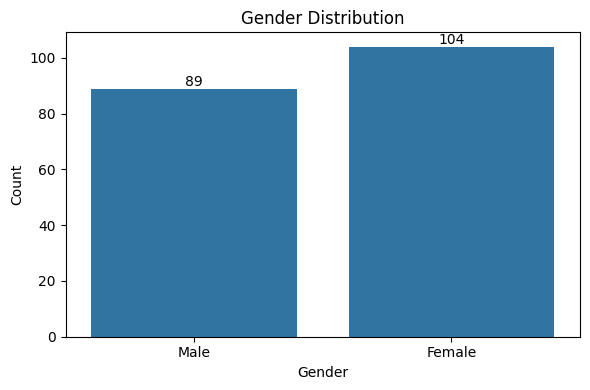

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='Q20')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# Education Distribution

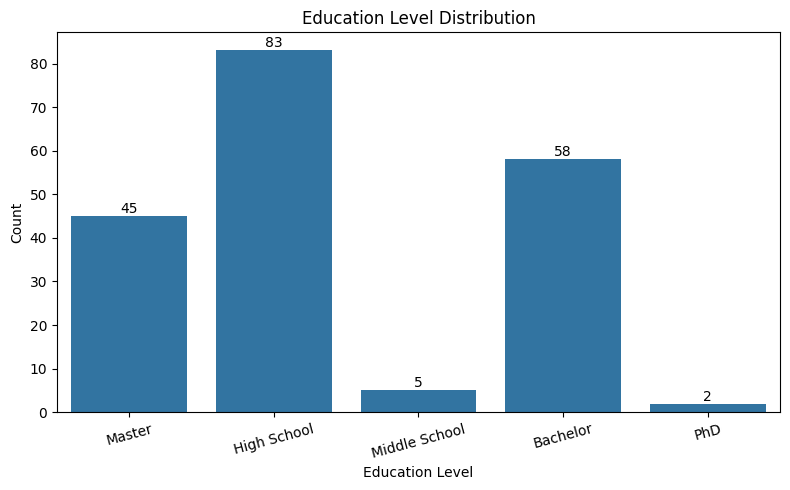

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='Q25')
plt.title('Education Level Distribution')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# Occupation Distribution

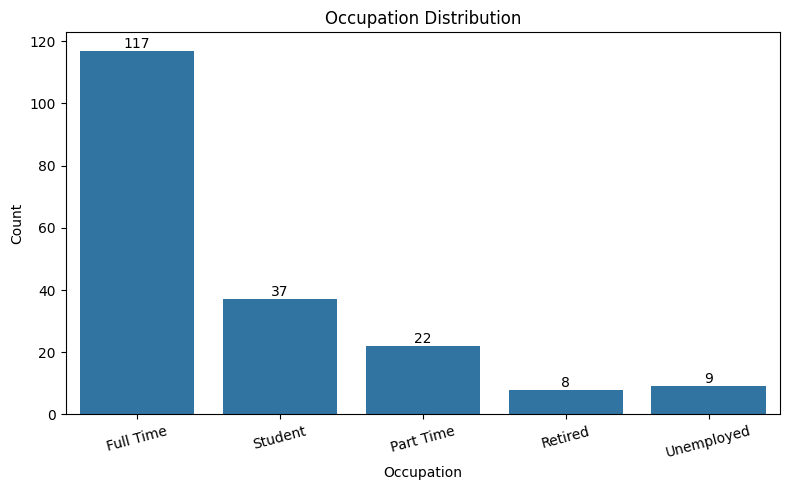

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='Q27')
plt.title('Occupation Distribution')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# Age Distribution

In [ ]:
age_bins = [20, 30, 40, 50, 60]
age_labels = ['20-29', '30-39', '40-49', '50-59']

df['Age_Group'] = pd.cut(
    df['Q19'],
    bins=age_bins,
    labels=age_labels,
    right=False
)


In [ ]:
df['Age_Group']

,Age_Group
0,20-29
1,20-29
2,20-29
3,50-59
4,50-59
...,...
188,20-29
189,20-29
190,20-29
191,40-49


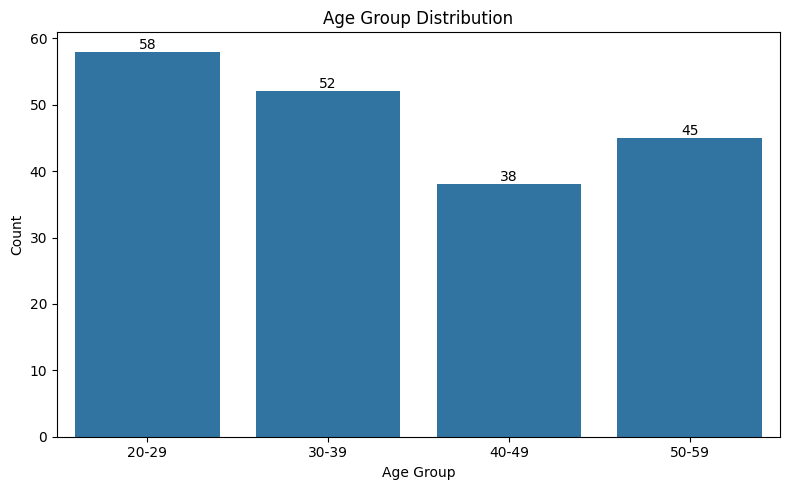

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x='Age_Group')

plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# Area of Origin

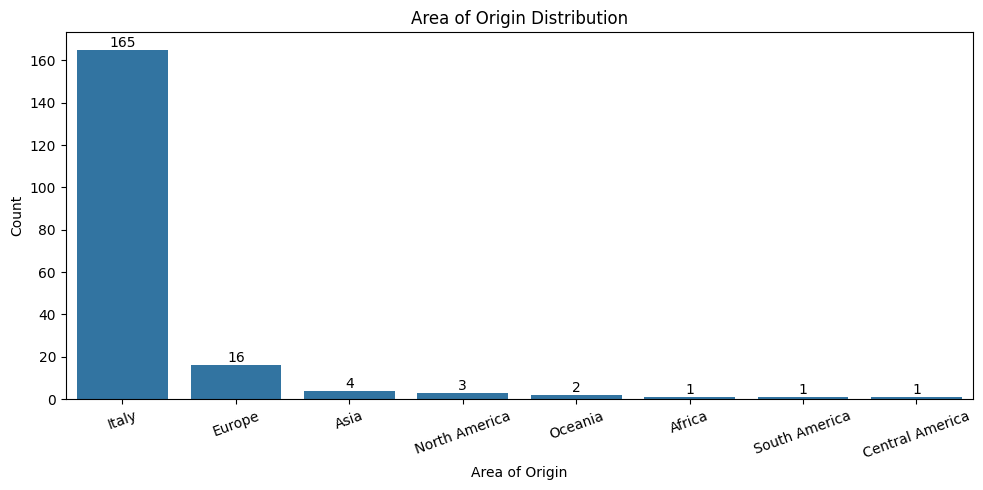

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x='Q22',
    order=df['Q22'].value_counts().index
)

plt.title('Area of Origin Distribution')
plt.xlabel('Area of Origin')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# Restaurant Visits per Month

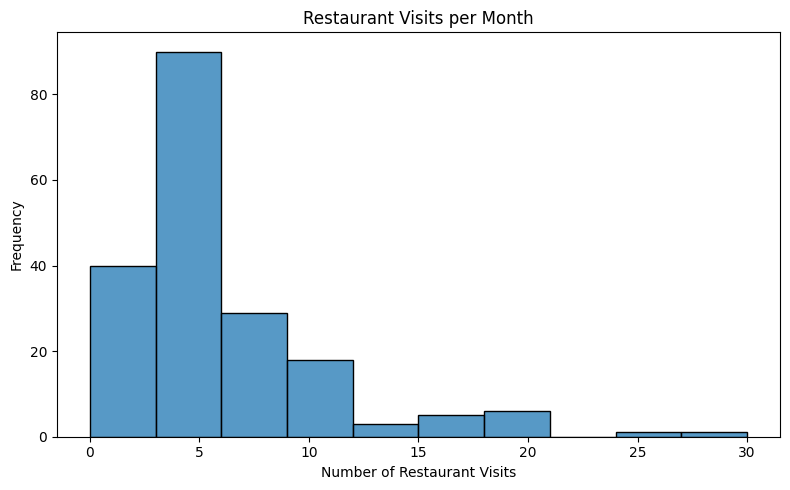

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.histplot(df['Q3'], bins=10)

plt.title('Restaurant Visits per Month')
plt.xlabel('Number of Restaurant Visits')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Average Spending in International Restaurants

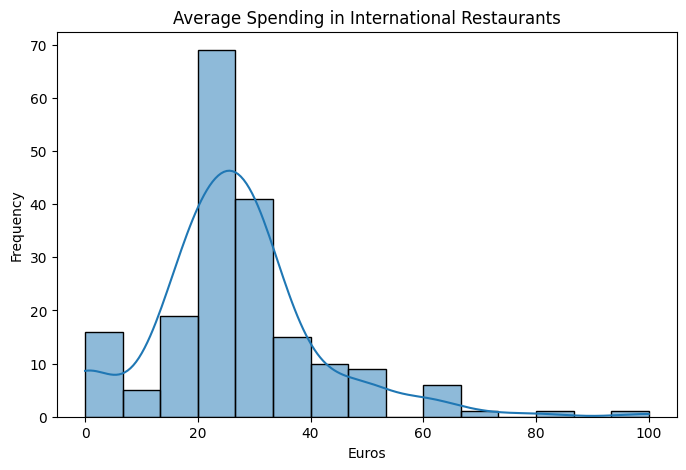

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Q5'], bins=15, kde=True)
plt.title('Average Spending in International Restaurants')
plt.xlabel('Euros')
plt.ylabel('Frequency')
plt.show()

# Restaurant Selection Criteria

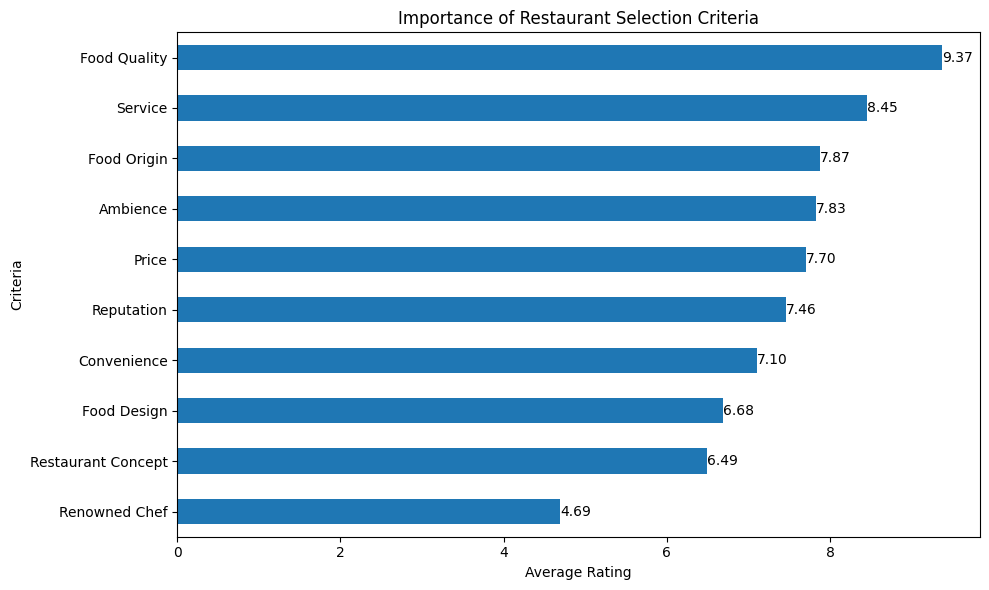

In [ ]:
# Q1 labels

q1_labels = {
    'Q1_1': 'Restaurant Concept',
    'Q1_2': 'Ambience',
    'Q1_3': 'Price',
    'Q1_4': 'Food Quality',
    'Q1_5': 'Service',
    'Q1_6': 'Food Origin',
    'Q1_7': 'Convenience',
    'Q1_8': 'Reputation',
    'Q1_9': 'Food Design',
    'Q1_10': 'Renowned Chef'
}

q1_means = df[list(q1_labels.keys())].mean()

q1_means.index = [q1_labels[col] for col in q1_means.index]

q1_means = q1_means.sort_values()


plt.figure(figsize=(10,6))

ax = q1_means.plot(kind='barh')

plt.title('Importance of Restaurant Selection Criteria')
plt.xlabel('Average Rating')
plt.ylabel('Criteria')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

# Awareness of Novel Food



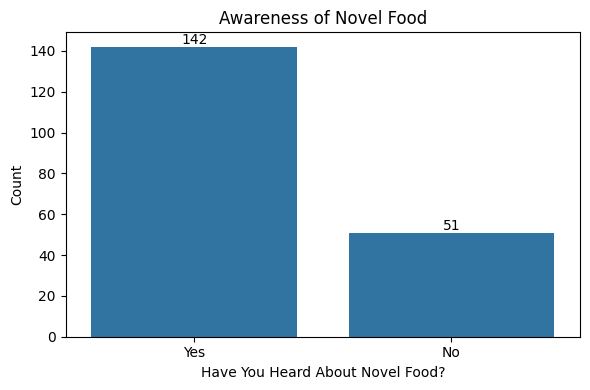

In [ ]:
q8_map = {
    1: 'Yes',
    0: 'No'
}

df['Q8_Label'] = df['Q8'].map(q8_map)


plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='Q8_Label')

plt.title('Awareness of Novel Food')
plt.xlabel('Have You Heard About Novel Food?')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# Willingness to try insects in Milan

*   List item
*   List item



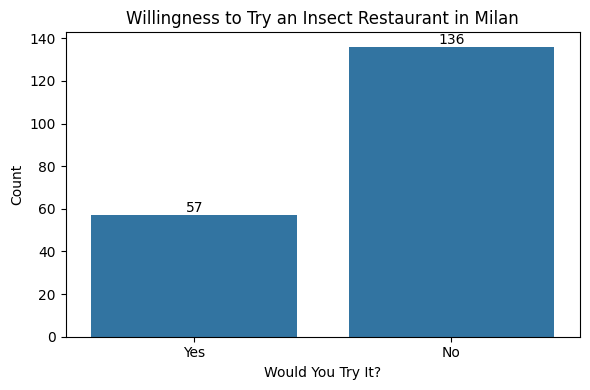

In [ ]:
q13_map = {
    1: 'Yes',
    0: 'No'
}

df['Q13_Label'] = df['Q13'].map(q13_map)

plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='Q13_Label')

plt.title('Willingness to Try an Insect Restaurant in Milan')
plt.xlabel('Would You Try It?')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

:# Factors Motivating Consumers to Try an Insect Restaurant

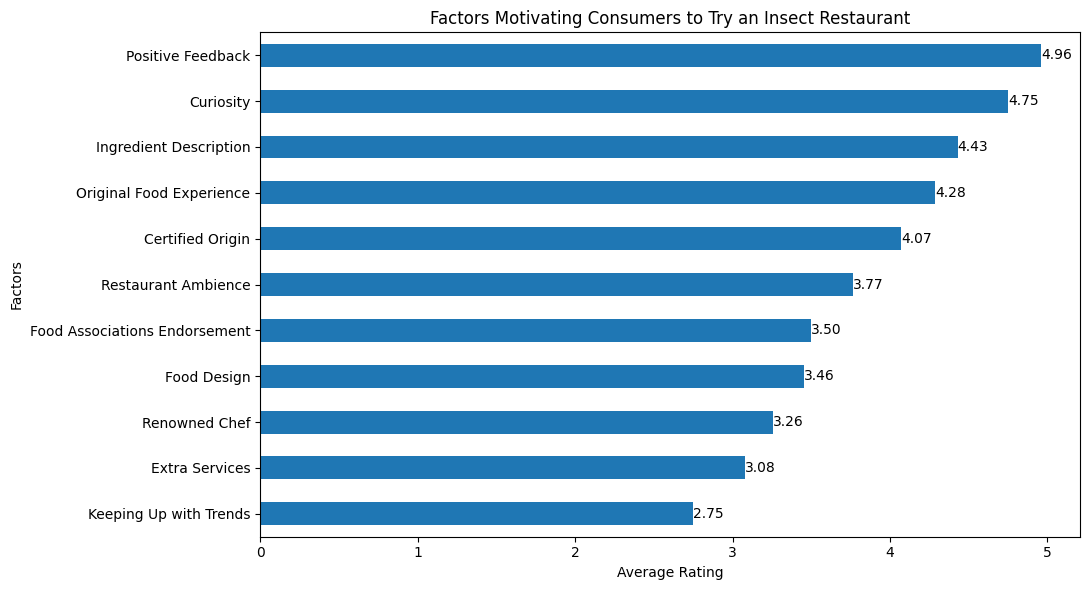

In [ ]:
q14_labels = {
    'Q14_1': 'Curiosity',
    'Q14_2': 'Original Food Experience',
    'Q14_3': 'Certified Origin',
    'Q14_4': 'Renowned Chef',
    'Q14_5': 'Restaurant Ambience',
    'Q14_6': 'Positive Feedback',
    'Q14_7': 'Ingredient Description',
    'Q14_8': 'Food Associations Endorsement',
    'Q14_9': 'Extra Services',
    'Q14_10': 'Keeping Up with Trends',
    'Q14_11': 'Food Design'
}


q14_means = df[list(q14_labels.keys())].mean()

q14_means.index = [q14_labels[col] for col in q14_means.index]

q14_means = q14_means.sort_values()


plt.figure(figsize=(11,6))

ax = q14_means.plot(kind='barh')

plt.title('Factors Motivating Consumers to Try an Insect Restaurant')
plt.xlabel('Average Rating')
plt.ylabel('Factors')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

# Personality Traits of Respondents

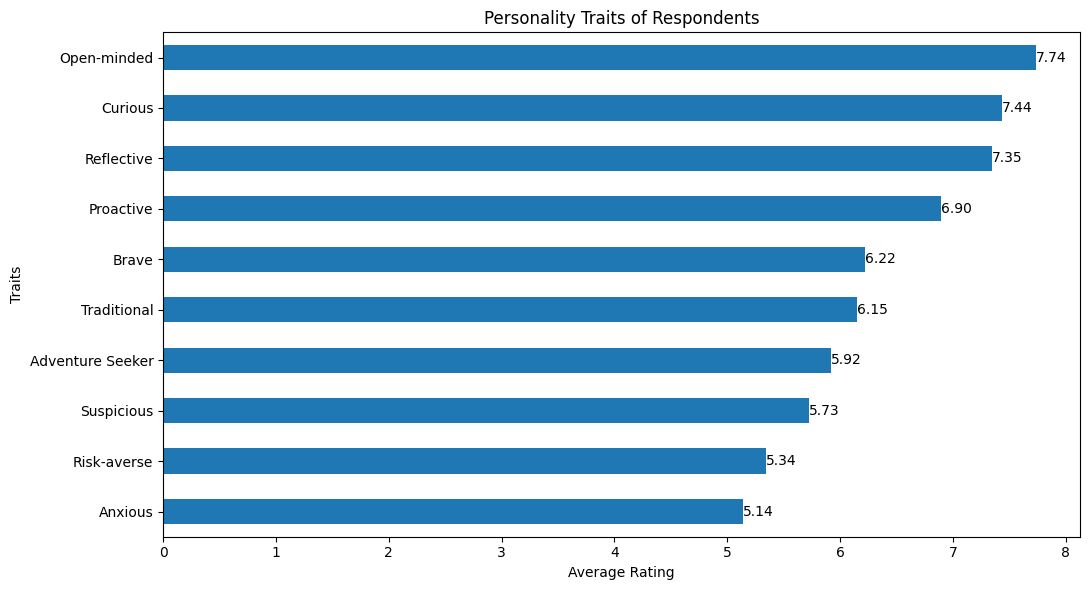

In [ ]:
q17_labels = {
    'Q17_1': 'Curious',
    'Q17_2': 'Traditional',
    'Q17_3': 'Brave',
    'Q17_4': 'Anxious',
    'Q17_5': 'Open-minded',
    'Q17_6': 'Reflective',
    'Q17_7': 'Adventure Seeker',
    'Q17_8': 'Suspicious',
    'Q17_9': 'Proactive',
    'Q17_10': 'Risk-averse'
}


q17_means = df[list(q17_labels.keys())].mean()

q17_means.index = [q17_labels[col] for col in q17_means.index]

q17_means = q17_means.sort_values()


plt.figure(figsize=(11,6))

ax = q17_means.plot(kind='barh')

plt.title('Personality Traits of Respondents')
plt.xlabel('Average Rating')
plt.ylabel('Traits')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

# Age Group vs Willingness to try Novel Food

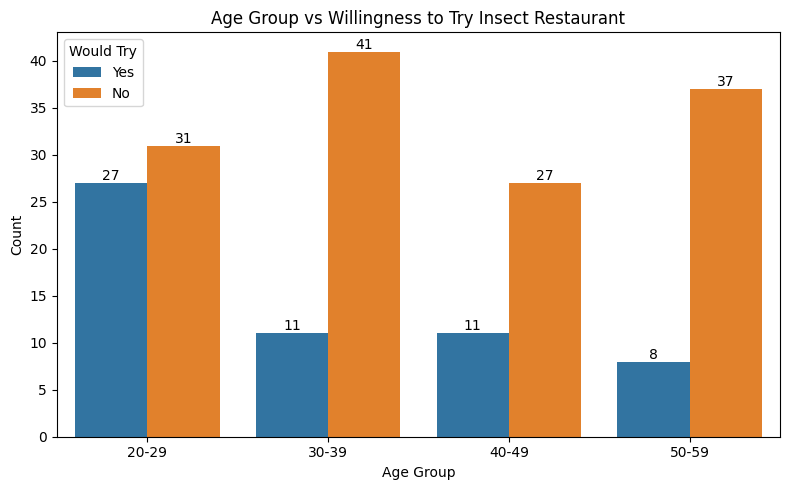

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Age_Group',
    hue='Q13_Label'
)

plt.title('Age Group vs Willingness to Try Insect Restaurant')
plt.xlabel('Age Group')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.legend(title='Would Try')

plt.tight_layout()
plt.show()

# Novel Food Awareness vs Willingness to Try

<Figure size 1400x800 with 0 Axes>

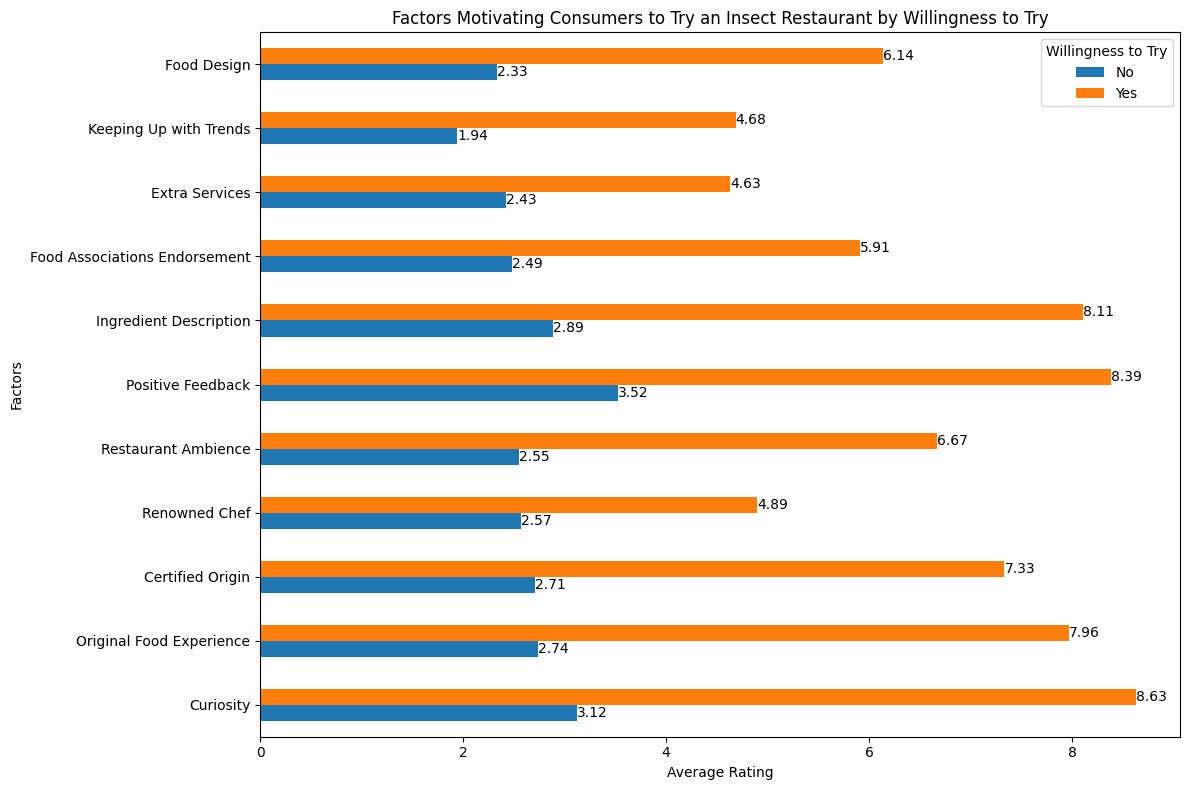

In [ ]:
q14_willingness_means = df.groupby('Q13_Label')[list(q14_labels.keys())].mean()

plt.figure(figsize=(14, 8))

q14_willingness_means_T = q14_willingness_means.T
q14_willingness_means_T.index = [q14_labels[col] for col in q14_willingness_means_T.index]

ax = q14_willingness_means_T.plot(kind='barh', figsize=(12, 8))

plt.title('Factors Motivating Consumers to Try an Insect Restaurant by Willingness to Try')
plt.xlabel('Average Rating')
plt.ylabel('Factors')
plt.legend(title='Willingness to Try')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

### Area of Origin vs Willingness to Try

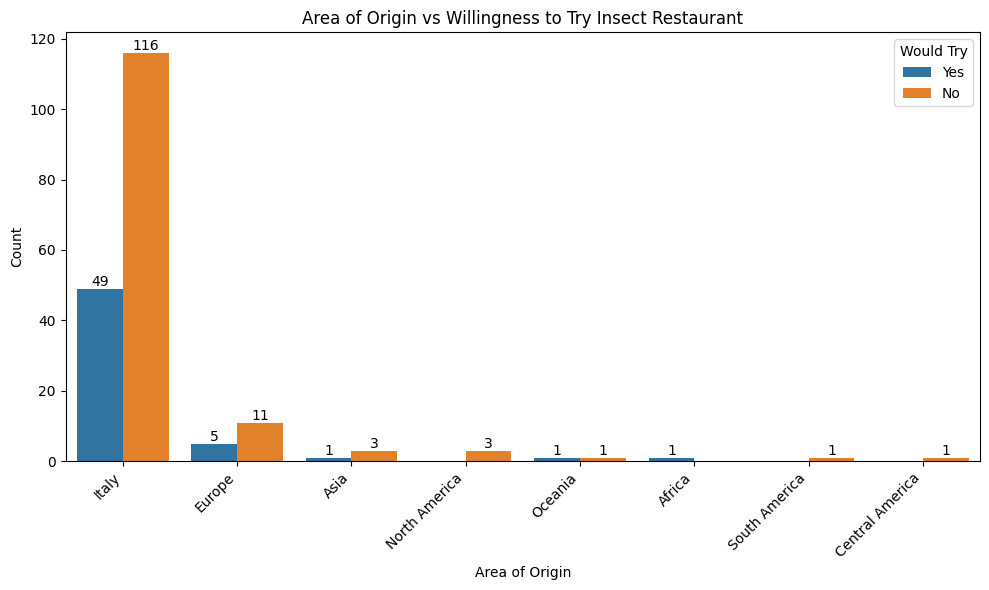

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x='Q22',
    hue='Q13_Label',
    order=df['Q22'].value_counts().index
)

plt.title('Area of Origin vs Willingness to Try Insect Restaurant')
plt.xlabel('Area of Origin')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45, ha='right')
plt.legend(title='Would Try')

plt.tight_layout()
plt.show()